<a href="https://colab.research.google.com/github/EthanFBusiness/EthanFBusiness.github.io/blob/main/Machine_Learning_project_wisconsin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Breast Cancer Prediction using Various Machine Learning Models

This project explores the use of different machine learning models to predict breast cancer malignancy based on the [Wisconsin Breast Cancer (Diagnostic) dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)). We will implement and compare a multi-layer perceptron (Neural Network), Logistic Regression, a single-hidden-layer Neural Network, and a Random Forest Classifier.

### Dataset Description
The dataset contains 569 samples of malignant and benign tumour cells. For each sample, 30 features are computed from a digitised image of a fine needle aspirate (FNA) of a breast mass. These features describe characteristics of the cell nuclei present in the image, such as:

*   **Radius:** Mean distance from centre to perimeter
*   **Texture:** Standard deviation of gray-scale values
*   **Perimeter:** Perimeter of the tumour
*   **Area:** Area of the tumour
*   **Smoothness:** Local variation in radius lengths
*   **Concavity:** Severity of concave portions of the contour
*   **Concave points:** Number of concave portions of the contour
*   **Symmetry:** Symmetry of the tumour


For each feature, the mean, standard error, and "worst" (largest) value were calculated, resulting in 30 features.

### Project Structure
1.  **Data Loading and Initial Exploration**
2.  **Data Preprocessing** (Splitting and Standardisation)
3.  **Neural Network (Multi-Layer Perceptron) Implementation**
4.  **Logistic Regression Implementation**
5.  **Single-Hidden-Layer Neural Network Implementation**
6.  **Random Forest Classifier Implementation**
7.  **Model Comparison and Evaluation**

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatthewAlexanderFisher/NCL-MAS3919/blob/main/content/practicals/assignment-setup.ipynb)

# Assignment Setup


## 1. Data Loading and Initial Exploration

First, we load the necessary libraries and the Wisconsin Breast Cancer dataset from `sklearn.datasets`. The dataset is then separated into features (`X`) and target labels (`y`).

In [147]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()

X = data.data
y = data.target

The dataset contains 569 instances with 30 features. The target variable `y` indicates the type of breast mass, where `0` represents malignant and `1` represents benign. The class distribution is 212 malignant (37.3%) and 357 benign (62.7%). While this is relatively balanced, ideally we would have a 50/50 split to avoid scenarios where batches contain only benign cases. The distribution of these classes is visualised using a pie chart to show the proportion of malignant versus benign cases (Figure 1).

(569, 30)
(569,)
[0 1] [212 357]


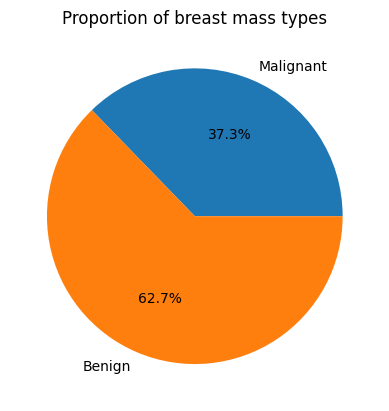

In [148]:

print(X.shape)
print(y.shape)
unique, counts = np.unique(y, return_counts=True)
print(unique, counts)
plt.pie(counts, labels = ['Malignant','Benign'], autopct='%1.1f%%')
plt.title('Proportion of breast mass types')
plt.show()

To get a better understanding of the features, we convert the feature array `X` into a pandas DataFrame and display the first 5 rows. This allows us to see the names and initial values of the features.

In [149]:
pandas_dataframe = pd.DataFrame(X, columns=data.feature_names)
pandas_dataframe.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Data Preprocessing

Before training our models, the data needs to be preprocessed. This involves splitting the data into training and testing sets and standardising the features.

### Data Splitting
We split the dataset using a 90/10 ratio, allocating 512 samples for training and 57 samples for testing. This custom split ensures that our model is trained on a substantial portion of the data and evaluated on unseen data. Evaluating on unseen data is crucial to check how well the model generalises, and to identify if it is *overfitting* to the training data. Overfitting occurs when a model learns patterns specific to the training set that do not apply to new, unseen data, rendering it less useful for real-world predictions. It's important to use a consistent split for fair comparison across different models. The data is converted to NumPy arrays for easier manipulation during this stage.

### Feature Standardisation
Feature standardisation is a crucial step for many machine learning algorithms, especially those that rely on distance calculations or gradient descent (like neural networks). It rescales the data to have a mean of 0 and a standard deviation of 1. This prevents features with larger numerical ranges from dominating the learning process and weight updates during gradient descent. We calculate the mean and standard deviation *only from the training set* to avoid data leakage from the test set.

### Mathematical Logic of Feature Standardisation

Feature standardisation (also known as Z-score normalisation) transforms each feature such that it has a mean of 0 and a standard deviation of 1. This is achieved using the following formula for each feature:

$$z = \frac{x - \mu}{\sigma}$$

Where:
*   $x$ is the original value of a feature.
*   $\mu$ is the mean of that feature calculated from the training data.
*   $\sigma$ is the standard deviation of that feature calculated from the training data.

Neural networks are particularly sensitive to the scale of input features. Applying standardisation ensures that most inputs are within a similar range (e.g., approximately {−1.96, 1.96} for data from a normal distribution), which prevents features with larger magnitudes from dominating the learning process and weight updates during gradient descent. It's critical that $\mu$ and $\sigma$ are computed *only* from the training set and then applied to both the training and test sets. This prevents data leakage from the test set into the training process, ensuring an unbiased evaluation of the model's performance on unseen data.

In [150]:
#Making a cutoff point (90% of the rows)
cutoff = np.round(np.shape(X)[0]*0.9, 0)

#Creating the np arrays for the test and train, splitting data into 80% training, 20% testing
X_train_np = X[0:int(cutoff),:]
y_train_np = y[0:int(cutoff),]

X_test_np = X[int(cutoff):,:]
y_test_np = y[int(cutoff):,]

#Calculating the mean and SD of each feature (from the training set)
mean_x = np.mean(X_train_np, axis=0)
stand_x = np.std(X_train_np, axis=0)

#Standardising the inputs
X_train_std = (X_train_np - mean_x)/stand_x
X_test_std = (X_test_np - mean_x)/stand_x

#Converting results to tensors
X_train = torch.tensor(X_train_std, dtype=torch.float32)
X_test = torch.tensor(X_test_std, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print(X_train.shape)
print(X_test.shape)


torch.Size([512, 30])
torch.Size([57, 30])


In [151]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim):
        super().__init__()
        # 1 input layers, 2 hidden layers
        self.layer1 = nn.Linear(input_dim, hidden_dim1)
        self.layer2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.layer3 = nn.Linear(hidden_dim2, output_dim)


    def forward(self, x):
        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        # Pass through Layer 1 and activate
        h1 = self.layer1(x)
        h1_activated = self.relu(h1)
        # Pass through Layer 2 and activate
        h2 = self.layer2(h1_activated)
        h2_activated = self.relu(h2)

        # Pass through Output Layer and make into probability
        output = self.sigmoid(self.layer3(h2_activated))

        return output

### Mathematical Representation of the Neural Network (Multi-Layer Perceptron)

The `Net` model defines a multi-layer perceptron with two hidden layers. Given an input vector $X$ (features of a single sample), the entire forward pass of the model can be represented as:

$$\hat{Y} = \sigma_s(\sigma_r(\sigma_r(X W_1 + B_1) W_2 + B_2) W_3 + B_3)$$

This single expression demonstrates the complete flow of data through the network, from the initial input $X$ to the final predicted probability $\hat{Y}$, highlighting the sequential application of linear transformations and activation functions across all layers.

Here:
*   $X$ is the input vector (features).
*   $W_1, W_2, W_3$ are the weight matrices for the first hidden, second hidden, and output layers, respectively.
*   $B_1, B_2, B_3$ are the bias vectors for the first hidden, second hidden, and output layers, respectively.
*   $\sigma_r$ represents the ReLU (Rectified Linear Unit) activation function, defined as $\sigma_r(z) = \max(0, z)$.
*   $\sigma_s$ represents the Sigmoid activation function, defined as $\sigma_s(z) = \frac{1}{1 + e^{-z}}$.

This $\hat{Y}$ represents the model's predicted probability of the sample belonging to the positive class (benign in this case).

### Calculating Trainable Parameters for the Neural Network

For a neural network, the total number of trainable parameters consists of the weights and biases for each linear layer. For a linear layer with `in_features` input units and `out_features` output units, the number of parameters is calculated as:

$$\text{Parameters} = (\text{in_features} \times \text{out_features}) + \text{out_features}$$

Where the first term represents the weights connecting the input to the output units, and the second term represents the bias for each output unit.

For our `Net` model defined as `Net(input_dim=30, hidden_dim1=16, hidden_dim2=8, output_dim=1)`:

1.  **Layer 1 (Input to Hidden Layer 1):**
    *   `input_dim` = 30
    *   `hidden_dim1` = 16
    *   Parameters = $(30 \times 16) + 16 = 480 + 16 = 496$

2.  **Layer 2 (Hidden Layer 1 to Hidden Layer 2):**
    *   `hidden_dim1` = 16
    *   `hidden_dim2` = 8
    *   Parameters = $(16 \times 8) + 8 = 128 + 8 = 136$

3.  **Layer 3 (Hidden Layer 2 to Output Layer):**
    *   `hidden_dim2` = 8
    *   `output_dim` = 1
    *   Parameters = $(8 \times 1) + 1 = 8 + 1 = 9$

**Total Trainable Parameters:**
Summing the parameters from all layers: $496 + 136 + 9 = 641$

In [152]:

layer_1 = 30*16 + 16
layer_2 = 16*8 + 8
layer_3 = 8*1 + 1

total_parameters = layer_1 + layer_2 + layer_3
print(total_parameters)

641


After instantiating the model and passing the `X_train` tensor through it, we check the shape of the output. The output shape `torch.Size([512, 1])` indicates that for each of the 512 training samples, the model produces a single probability value, which is consistent with our binary classification task where we predict the likelihood of a sample being benign.

In [153]:
model = Net(input_dim=30, hidden_dim1=16, hidden_dim2=8, output_dim=1)

model_output = model(X_train)
print(model_output.shape)

torch.Size([512, 1])


### Training Loop and Loss Function

This section defines and executes the training process for the multi-layer perceptron. The core idea of training a neural network is to iteratively adjust its parameters (weights and biases) to minimise a predefined loss function.

#### Loss Function: Binary Cross-Entropy (BCE)
For binary classification tasks like breast cancer prediction, where the output is a probability between 0 and 1, **Binary Cross-Entropy (BCE) Loss** is commonly used. It measures the performance of a classification model whose output is a probability value between 0 and 1. The formula for BCE loss for a single sample is:

$$L = -[y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})]$$

Where:
*   $y$ is the true label (0 for malignant, 1 for benign).
*   $\hat{y}$ (y-hat) is the predicted probability of the sample being benign.

`nn.BCELoss()` in PyTorch computes this loss across a batch of samples.

#### Optimiser: Adam
The **Adam (Adaptive Moment Estimation) optimiser** is an algorithm for gradient-based optimisation of stochastic objective functions. It's popular for its efficiency and good performance in practice. It combines the advantages of two other extensions of stochastic gradient descent: Adaptive Gradient Algorithm (AdaGrad) and Root Mean Square Propagation (RMSProp).

`optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)` initialises the optimiser with:
*   `model.parameters()`: The parameters (weights and biases) of the neural network that need to be optimised.
*   `lr=0.001`: The learning rate, which controls the step size during parameter updates.
.

#### Training Loop Steps
1.  **`model.train()`**: Sets the model to training mode. This affects layers like Dropout and BatchNorm, ensuring they behave as expected during training.
2.  **`optimiser.zero_grad()`**: Clears the gradients of all optimised tensors. Gradients accumulate by default in PyTorch, so this step is crucial to prevent gradients from previous batches affecting the current update.
3.  **`outputs = model(X_batch)`**: Performs a forward pass through the network, taking the input `X_batch` and producing predictions `outputs`.
4.  **`current_batch_loss = loss_fn(outputs, y_batch.unsqueeze(1))`**: Calculates the loss between the model's predictions (`outputs`) and the true labels (`y_batch`). `y_batch.unsqueeze(1)` reshapes the target tensor to match the output tensor's shape.
5.  **`current_batch_loss.backward()`**: Performs backpropagation. This computes the gradient of the loss with respect to each parameter in the model.
6.  **`optimiser.step()`**: Updates the model's parameters using the calculated gradients and the chosen optimisation algorithm (Adam).
7.  **Evaluation on Test Set**: After each epoch, the model is set to `model.eval()` mode (disabling gradient calculation with `torch.no_grad()`) to evaluate its performance on the test set. This helps monitor for overfitting.

In [154]:
loss_fn = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=0.001)


In [155]:
from torch.utils.data import TensorDataset, DataLoader


train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32


train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


#Training Loop
num_epochs = 100


all_epoch_losses = [] # List to store the average loss of each epoch
all_test_epoch_losses = [] # list to store test loss per epoch

for epoch in range(num_epochs):
    model.train()
    losses_per_batch_this_epoch = [] # List to store loss for each batch within the current epoch

    for X_batch, y_batch in train_loader:
        optimiser.zero_grad()

        outputs = model(X_batch) # Forward pass

        current_batch_loss = loss_fn(outputs, y_batch.unsqueeze(1)) # Computation of the loss

        current_batch_loss.backward() # Backpropagation

        losses_per_batch_this_epoch.append(current_batch_loss.item()) # Save the scalar loss for this iteration/batch

        optimiser.step()  #Parameter updates

    # Calculate average training loss for the current epoch
    avg_epoch_loss = sum(losses_per_batch_this_epoch) / len(losses_per_batch_this_epoch)
    all_epoch_losses.append(avg_epoch_loss)

    # --- Evaluate on test set after each epoch to check for overfitting---
    model.eval() # Set model to evaluation mode
    test_losses_this_epoch = []
    with torch.no_grad():
        for X_batch_test, y_batch_test in test_loader:
            test_outputs = model(X_batch_test)
            test_loss = loss_fn(test_outputs, y_batch_test.unsqueeze(1))
            test_losses_this_epoch.append(test_loss.item())
    avg_test_epoch_loss = sum(test_losses_this_epoch) / len(test_losses_this_epoch)
    all_test_epoch_losses.append(avg_test_epoch_loss)
    model.train() # Set model back to training mode
    # ----------------------------------------------

    # Print loss after each epoch (every 10 epochs)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Avg Train Loss: {avg_epoch_loss:.4f}, Avg Test Loss: {avg_test_epoch_loss:.4f}')

print("Training finished.\n")
print("All Epoch Training Losses:", all_epoch_losses)
print("All Epoch Test Losses:", all_test_epoch_losses)

Number of training batches: 16
Number of testing batches: 2
Epoch [10/100], Avg Train Loss: 0.1399, Avg Test Loss: 0.1115
Epoch [20/100], Avg Train Loss: 0.0667, Avg Test Loss: 0.0790
Epoch [30/100], Avg Train Loss: 0.0516, Avg Test Loss: 0.0794
Epoch [40/100], Avg Train Loss: 0.0424, Avg Test Loss: 0.0825
Epoch [50/100], Avg Train Loss: 0.0346, Avg Test Loss: 0.0815
Epoch [60/100], Avg Train Loss: 0.0276, Avg Test Loss: 0.0788
Epoch [70/100], Avg Train Loss: 0.0224, Avg Test Loss: 0.0742
Epoch [80/100], Avg Train Loss: 0.0176, Avg Test Loss: 0.0747
Epoch [90/100], Avg Train Loss: 0.0140, Avg Test Loss: 0.0791
Epoch [100/100], Avg Train Loss: 0.0115, Avg Test Loss: 0.0795
Training finished.

All Epoch Training Losses: [0.6408238708972931, 0.5850800201296806, 0.5175459440797567, 0.4421579074114561, 0.36599219776690006, 0.2994854124262929, 0.24356511048972607, 0.19861777173355222, 0.1638703658245504, 0.1398509219288826, 0.1218662466853857, 0.10840296419337392, 0.09855251503176987, 0.0909

### Model Evaluation on Test Set

After training, the model's performance is assessed on the unseen test set to ensure it generalises well to new data. We use the following metrics:

1.  **Accuracy**: The proportion of correctly classified instances out of the total instances. It is calculated as:
$$\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$$



2.  **Confusion Matrix**: A table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualisation of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class, or vice versa. For binary classification, it typically has four entries:
    *   **True Positives (TP)**: Correctly predicted positive cases.
    *   **True Negatives (TN)**: Correctly predicted negative cases.
    *   **False Positives (FP)**: Incorrectly predicted positive cases (Type I error).
    *   **False Negatives (FN)**: Incorrectly predicted negative cases (Type II error).

    The confusion matrix provides a more detailed insight into the types of errors made by the classifier than just accuracy alone. It will be visualised using a heatmap for clarity.

### Interpreting the Results for the Multi-Layer Perceptron

The model achieved an **accuracy of 0.9649** on the test set. Examining the confusion matrix, which is generated from the model's predictions on the `X_test` data:

*   **True Positives (TP = 41)**: 41 benign cases were correctly identified as benign.
*   **True Negatives (TN = 14)**: 14 malignant cases were correctly identified as malignant.
*   **False Positives (FP = 0)**: 0 malignant cases were incorrectly classified as benign. This is a very good outcome as misclassifying malignant as benign could have serious consequences.
*   **False Negatives (FN = 2)**: 2 benign cases were incorrectly classified as malignant. This means the model predicted these 2 benign cases to be malignant.

In [156]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Test the Model
model.eval()  # Set the model to evaluation mode

with torch.no_grad():  # Disable gradient calculation during evaluation

    all_predicted = [] # Vector of all predicted outcomes
    all_targets = [] # Vector of the actuall outcomes

    for X_batch_test, y_batch_test in test_loader:
        test_outputs = model(X_batch_test)

        # Convert probabilities to binary predictions (0 or 1)
        predicted = (test_outputs >= 0.5).float()

        all_predicted.append(predicted)
        all_targets.append(y_batch_test.unsqueeze(1))

    # Concatenate all batches to calculate overall accuracy
    predicted_combined = torch.cat(all_predicted)
    targets_combined = torch.cat(all_targets)

    # Calculate accuracy
    correct = (predicted_combined == targets_combined).sum().item()
    total = targets_combined.size(0)
    accuracy = round((correct / total), 6)

    print(f"Model Accuracy: {accuracy}")

    # Calculate Confusion Matrix
    cm = confusion_matrix(targets_combined.cpu().numpy(), predicted_combined.cpu().numpy())



Model Accuracy: 0.964912


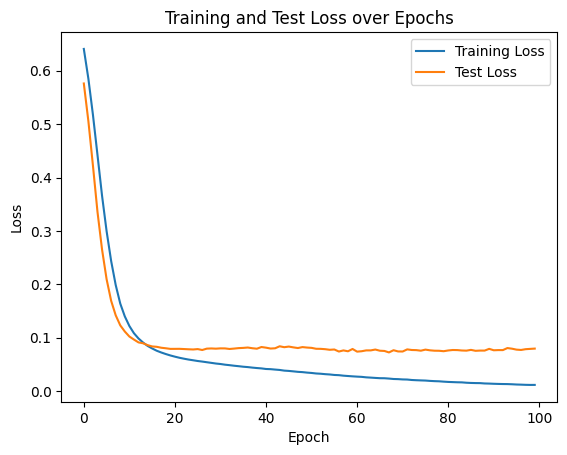

In [157]:
all_epoch_losses = np.array(all_epoch_losses)
plt.plot(all_epoch_losses)

plt.plot(all_test_epoch_losses)
plt.legend(['Training Loss', 'Test Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')


plt.show()


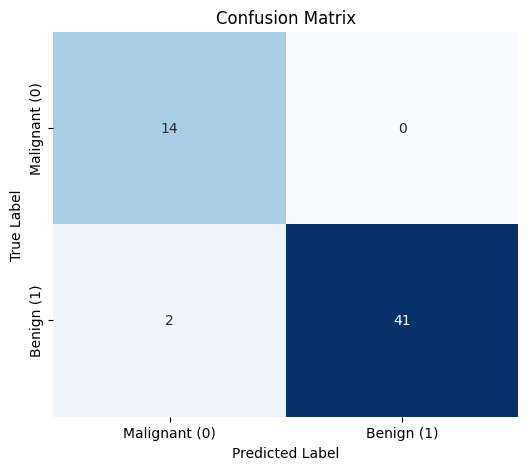

In [158]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=['Malignant (0)', 'Benign (1)'], yticklabels=['Malignant (0)', 'Benign (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 4. Logistic Regression Implementation

Logistic Regression, despite its name, is a linear model for binary classification rather than regression. It's fundamentally simpler than a multi-layer perceptron, lacking hidden layers. It takes a linear combination of input features and then applies a sigmoid activation function to output a probability.

### Mathematical Representation of Logistic Regression

For an input vector $X$ (features of a single sample), the predicted probability $\hat{Y}$ is given by:

$$\hat{Y} = \sigma(X W + B)$$

Where:
*   $X$ is the input vector (features).
*   $W$ is the weight vector.
*   $B$ is the bias term.
*   $\sigma$ represents the Sigmoid activation function, defined as $\sigma(z) = \frac{1}{1 + e^{-z}}$.

This output $\hat{Y}$ represents the probability of the sample belonging to the positive class (e.g., benign). The model essentially fits a linear decision boundary to separate the classes, and the sigmoid function squashes this linear output into a probability range of 0 to 1.

### Why Logistic Regression Can Be Effective (and when it might not be)

Despite its simplicity, Logistic Regression can be highly effective, especially when:
*   **Data is Linearly Separable:** If the classes can be separated by a straight line (or hyperplane in higher dimensions), Logistic Regression can perform very well.
*   **Interpretability is Key:** With fewer parameters and a direct relationship between inputs and outputs, it's easier to interpret which features are most influential.
*   **Computational Efficiency:** It's less computationally intensive to train and deploy compared to more complex models.

While a multi-layer perceptron (like the `Net` model) has the capacity to learn more complex, non-linear relationships due to its hidden layers and multiple activation steps, this complexity isn't always necessary or beneficial. In some cases, a simpler model like Logistic Regression might:
*   **Generalise Better:** If the dataset is small or the underlying patterns are indeed linear, complex models can easily overfit the training data, leading to poorer performance on unseen test data. A simpler model with fewer parameters (like Logistic Regression) is less prone to overfitting.
*   **Be More Robust to Noise:** Simpler models might be less sensitive to noise in the data.

In this particular breast cancer dataset, even though the multi-layer perceptron and the single-hidden-layer network (Net2) might achieve similar or slightly higher accuracy, it's valuable to compare with Logistic Regression to understand the baseline performance and determine if the added complexity of neural networks is truly yielding significant improvements. It's often a good practice to start with simpler models and only move to more complex ones if the simpler models prove insufficient.

In [159]:
import torch.nn as nn

# Define the Logistic Regression Model
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1) # Single linear layer
        self.sigmoid = nn.Sigmoid() # Sigmoid activation for binary classification

    def forward(self, x):
        out = self.linear(x)
        out = self.sigmoid(out)
        return out

# Instantiate the new model
logistic_model = LogisticRegression(input_dim=30)

# Define loss function and optimizer for the new model
loss_fn_logistic = nn.BCELoss()
optimiser_logistic = optim.Adam(logistic_model.parameters(), lr=0.001)

print("Logistic Regression model created.")

Logistic Regression model created.


In [160]:
# Training Loop for Logistic Regression
num_epochs_logistic = 100 # Using 100 epochs for consistency with the previous model

all_epoch_losses_logistic = [] # Store training loss per epoch
all_test_epoch_losses_logistic = [] # Store test loss per epoch for Logistic Regression

print("Starting Logistic Regression training...")
for epoch in range(num_epochs_logistic):
    logistic_model.train() # Set model to training mode
    losses_per_batch_this_epoch = []

    for X_batch, y_batch in train_loader:
        optimiser_logistic.zero_grad()
        outputs = logistic_model(X_batch)
        current_batch_loss = loss_fn_logistic(outputs, y_batch.unsqueeze(1))
        current_batch_loss.backward()
        losses_per_batch_this_epoch.append(current_batch_loss.item())
        optimiser_logistic.step()

    avg_epoch_loss = sum(losses_per_batch_this_epoch) / len(losses_per_batch_this_epoch)
    all_epoch_losses_logistic.append(avg_epoch_loss)

    # Evaluate on test set after each epoch for Logistic Regression
    logistic_model.eval() # Set model to evaluation mode
    test_losses_this_epoch = []
    with torch.no_grad():
        for X_batch_test, y_batch_test in test_loader:
            test_outputs = logistic_model(X_batch_test)
            test_loss = loss_fn_logistic(test_outputs, y_batch_test.unsqueeze(1))
            test_losses_this_epoch.append(test_loss.item())
    avg_test_epoch_loss = sum(test_losses_this_epoch) / len(test_losses_this_epoch)
    all_test_epoch_losses_logistic.append(avg_test_epoch_loss)
    logistic_model.train() # Set model back to training mode

    # Print loss after each epoch (every 10 epochs)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_logistic}], LR Avg Train Loss: {avg_epoch_loss:.4f}, LR Avg Test Loss: {avg_test_epoch_loss:.4f}')

print("Logistic Regression Training finished.\n")
print("LR All Epoch Training Losses:", all_epoch_losses_logistic)
print("LR All Epoch Test Losses:", all_test_epoch_losses_logistic)

Starting Logistic Regression training...
Epoch [10/100], LR Avg Train Loss: 0.2261, LR Avg Test Loss: 0.2280
Epoch [20/100], LR Avg Train Loss: 0.1559, LR Avg Test Loss: 0.1631
Epoch [30/100], LR Avg Train Loss: 0.1254, LR Avg Test Loss: 0.1357
Epoch [40/100], LR Avg Train Loss: 0.1082, LR Avg Test Loss: 0.1208
Epoch [50/100], LR Avg Train Loss: 0.0973, LR Avg Test Loss: 0.1113
Epoch [60/100], LR Avg Train Loss: 0.0896, LR Avg Test Loss: 0.1047
Epoch [70/100], LR Avg Train Loss: 0.0840, LR Avg Test Loss: 0.0999
Epoch [80/100], LR Avg Train Loss: 0.0795, LR Avg Test Loss: 0.0959
Epoch [90/100], LR Avg Train Loss: 0.0760, LR Avg Test Loss: 0.0928
Epoch [100/100], LR Avg Train Loss: 0.0731, LR Avg Test Loss: 0.0902
Logistic Regression Training finished.

LR All Epoch Training Losses: [0.5112143792212009, 0.44036285392940044, 0.386973662301898, 0.34636665508151054, 0.3151524495333433, 0.29044335428625345, 0.2700558016076684, 0.2533587533980608, 0.2387765310704708, 0.22611933760344982, 0.21

Logistic Regression Test Accuracy: 0.964912


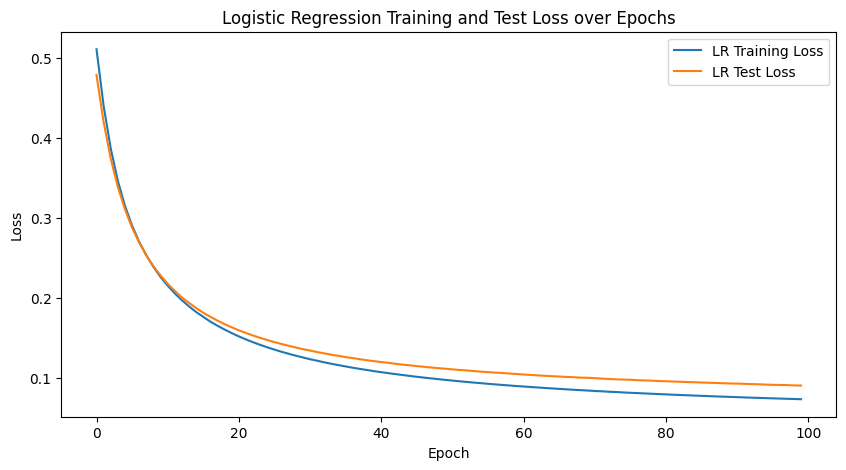

In [161]:
# Testing block for Logistic Regression
logistic_model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation
    # Predict on the entire test set (without explicit batching for final accuracy calculation)
    test_outputs_full = logistic_model(X_test)
    predicted_full = (test_outputs_full >= 0.5).float()

    # Calculate accuracy
    correct = (predicted_full == y_test.unsqueeze(1)).sum().item()
    total = y_test.size(0)
    accuracy_logistic = round((correct / total), 6)

    print(f'Logistic Regression Test Accuracy: {accuracy_logistic}')

# Plotting training and test loss for Logistic Regression
plt.figure(figsize=(10, 5))
plt.plot(all_epoch_losses_logistic, label='LR Training Loss')
plt.plot(all_test_epoch_losses_logistic, label='LR Test Loss')
plt.title('Logistic Regression Training and Test Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Interpreting the Results for Logistic Regression

The Logistic Regression model achieved an **accuracy of 0.964912** on the test set, which is comparable to the multi-layer perceptron (also around 0.9649).

However, when observing the loss plots, it's notable that the final test loss for the Logistic Regression model (`LR Avg Test Loss: 0.0902` in the last epoch) is higher than the final test loss for the multi-layer perceptron (`Avg Test Loss: 0.0795` in the last epoch). This suggests that while both models achieve similar accuracy on this specific test set, the multi-layer perceptron might have a slightly better understanding of the underlying data distribution, leading to a lower overall loss value. This difference, although small, indicates the multi-layer perceptron might be marginally better at predicting probabilities for individual samples.

### Mathematical Representation of the Single-Hidden-Layer Neural Network (Net2)

For an input vector $X$, the forward pass of our `Net2` model (with one hidden layer) can be represented as:

$$\hat{Y} = \sigma_s(\sigma_r(X W_1 + B_1) W_2 + B_2)$$

Here:
*   $X$ is the input vector.
*   $W_1, B_1$ are the weight matrix and bias vector for the hidden layer.
*   $W_2, B_2$ are the weight matrix and bias vector for the output layer.
*   $\sigma_r$ is the ReLU activation function.
*   $\sigma_s$ is the Sigmoid activation function.

This simplified architecture reduces the total number of trainable parameters, which can lead to faster training and potentially better generalisation on smaller datasets by reducing the model's capacity to overfit.

### Introduction of L2 Regularisation (Weight Decay)

To further combat overfitting and encourage the model to learn simpler, more generalisable patterns, we introduce **L2 Regularisation**, also known as **Weight Decay**. L2 regularisation adds a penalty to the loss function proportional to the square of the magnitude of the model's weights. The modified loss function becomes:

$$L_{total} = L_{original} + \lambda \sum_{i} |\|\theta_i\||^2$$

Where:
*   $L_{original}$ is the original loss function (e.g., Binary Cross-Entropy).
*   $\lambda$ (lambda) is the regularisation strength (a hyperparameter).
*   $\sum_{i} |\|\theta_i\||^2$ represents the sum of the squares of all the model's weights (excluding biases, though sometimes biases are also regularised).

**What it does:** By penalising large weights, L2 regularisation effectively drives weight values towards zero (but not exactly zero, unlike L1 regularisation). This prevents any single feature from dominating the model's predictions and encourages the model to use all features more evenly. It implicitly simplifies the model by reducing the effective complexity of the learned decision boundary.

**Why it's a smart move:** Both reducing the number of hidden layers and adding L2 regularisation are strategies to control model complexity. A less complex model is less likely to memorise the training data (overfit) and generally performs better on unseen data when the underlying patterns are not excessively intricate or when the dataset is not extremely large. For this breast cancer dataset, which is relatively small (569 samples), a simpler model with regularisation is often a more robust choice.

In [162]:
import torch.nn as nn

# Define the Net2 model with one hidden layer
class Net2(nn.Module):
    def __init__(self, input_dim, hidden_dim1, output_dim):
        super().__init__()
        # 1 input layer, 1 hidden layer
        self.layer1 = nn.Linear(input_dim, hidden_dim1)
        self.layer2 = nn.Linear(hidden_dim1, output_dim)

        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pass through Layer 1 and activate
        h1 = self.layer1(x)
        h1_activated = self.relu(h1)

        # Pass through Output Layer and make into probability
        output = self.sigmoid(self.layer2(h1_activated))

        return output

print("Net2 model class defined.")

Net2 model class defined.


In [163]:
# Calculate total parameters for Net2
# input_dim=30, hidden_dim1=16, output_dim=1
layer_1_net2 = 30*16 + 16 # Input to hidden_dim1
layer_2_net2 = 16*1 + 1   # hidden_dim1 to output_dim

total_parameters_net2 = layer_1_net2 + layer_2_net2
print(f"Total parameters for Net2 (one hidden layer): {total_parameters_net2}")

Total parameters for Net2 (one hidden layer): 513


In [164]:
# Instantiate Net2 model
model_net2 = Net2(input_dim=30, hidden_dim1=16, output_dim=1)

# Define loss function and optimizer for Net2
loss_fn_net2 = nn.BCELoss()
optimiser_net2 = optim.Adam(model_net2.parameters(), lr=0.001, weight_decay=0.001)

print("Net2 model instantiated and optimiser/loss defined.")

Net2 model instantiated and optimizer/loss defined.


In [165]:
# Training Loop for Net2 (one hidden layer)
num_epochs_net2 = 100 # Using 100 epochs for consistency

all_epoch_losses_net2 = [] # Store training loss per epoch
all_test_epoch_losses_net2 = [] # Store test loss per epoch

print("Starting Net2 training...")
for epoch in range(num_epochs_net2):
    model_net2.train() # Set model to training mode
    losses_per_batch_this_epoch = []

    for X_batch, y_batch in train_loader:
        optimiser_net2.zero_grad()
        outputs = model_net2(X_batch)
        current_batch_loss = loss_fn_net2(outputs, y_batch.unsqueeze(1))
        current_batch_loss.backward()
        losses_per_batch_this_epoch.append(current_batch_loss.item())
        optimiser_net2.step()

    avg_epoch_loss = sum(losses_per_batch_this_epoch) / len(losses_per_batch_this_epoch)
    all_epoch_losses_net2.append(avg_epoch_loss)

    # Evaluate on test set after each epoch
    model_net2.eval() # Set model to evaluation mode
    test_losses_this_epoch = []
    with torch.no_grad():
        for X_batch_test, y_batch_test in test_loader:
            test_outputs = model_net2(X_batch_test)
            test_loss = loss_fn_net2(test_outputs, y_batch_test.unsqueeze(1))
            test_losses_this_epoch.append(test_loss.item())
    avg_test_epoch_loss = sum(test_losses_this_epoch) / len(test_losses_this_epoch)
    all_test_epoch_losses_net2.append(avg_test_epoch_loss)
    model_net2.train() # Set model back to training mode

    # Print loss after each epoch (every 10 epochs)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_net2}], Net2 Avg Train Loss: {avg_epoch_loss:.4f}, Net2 Avg Test Loss: {avg_test_epoch_loss:.4f}')

print("Net2 Training finished.\n")
print("Net2 All Epoch Training Losses:", all_epoch_losses_net2)
print("Net2 All Epoch Test Losses:", all_test_epoch_losses_net2)

Starting Net2 training...
Epoch [10/100], Net2 Avg Train Loss: 0.1489, Net2 Avg Test Loss: 0.1393
Epoch [20/100], Net2 Avg Train Loss: 0.0824, Net2 Avg Test Loss: 0.0981
Epoch [30/100], Net2 Avg Train Loss: 0.0633, Net2 Avg Test Loss: 0.0858
Epoch [40/100], Net2 Avg Train Loss: 0.0541, Net2 Avg Test Loss: 0.0799
Epoch [50/100], Net2 Avg Train Loss: 0.0478, Net2 Avg Test Loss: 0.0774
Epoch [60/100], Net2 Avg Train Loss: 0.0434, Net2 Avg Test Loss: 0.0759
Epoch [70/100], Net2 Avg Train Loss: 0.0398, Net2 Avg Test Loss: 0.0731
Epoch [80/100], Net2 Avg Train Loss: 0.0367, Net2 Avg Test Loss: 0.0714
Epoch [90/100], Net2 Avg Train Loss: 0.0342, Net2 Avg Test Loss: 0.0697
Epoch [100/100], Net2 Avg Train Loss: 0.0314, Net2 Avg Test Loss: 0.0690
Net2 Training finished.

Net2 All Epoch Training Losses: [0.5940919108688831, 0.4901587441563606, 0.4051246605813503, 0.33554866537451744, 0.2812936305999756, 0.23923284653574228, 0.20752493664622307, 0.1831604242324829, 0.16446823673322797, 0.148920954

Net2 Test Accuracy (one hidden layer): 0.9649


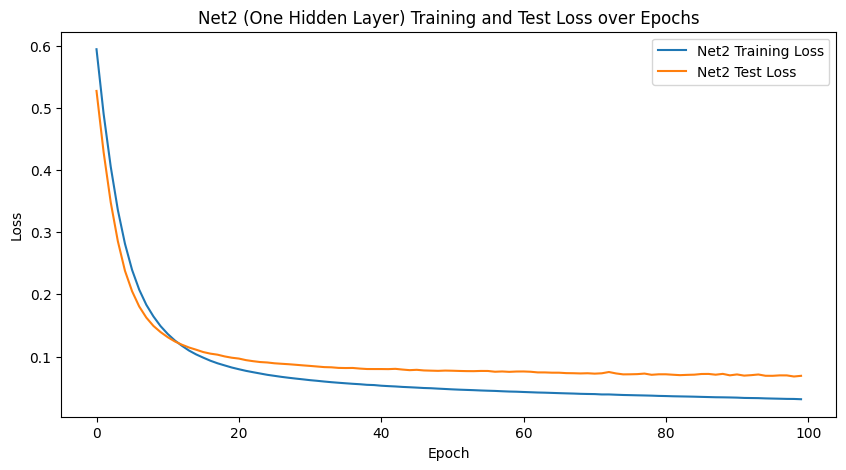

In [166]:
# Testing block for Net2
model_net2.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation
    # Predict on the entire test set (using test_loader for consistency, but you can use X_test directly too)
    all_predicted_net2 = []
    all_targets_net2 = []

    for X_batch_test, y_batch_test in test_loader:
        test_outputs = model_net2(X_batch_test)
        predicted = (test_outputs >= 0.5).float()

        all_predicted_net2.append(predicted)
        all_targets_net2.append(y_batch_test.unsqueeze(1))

    predicted_combined_net2 = torch.cat(all_predicted_net2)
    targets_combined_net2 = torch.cat(all_targets_net2)

    # Calculate accuracy
    correct_net2 = (predicted_combined_net2 == targets_combined_net2).sum().item()
    total_net2 = targets_combined_net2.size(0)
    accuracy_net2 = round((correct_net2 / total_net2), 4)

    print(f'Net2 Test Accuracy (one hidden layer): {accuracy_net2}')

# Plotting training and test loss for Net2
plt.figure(figsize=(10, 5))
plt.plot(all_epoch_losses_net2, label='Net2 Training Loss')
plt.plot(all_test_epoch_losses_net2, label='Net2 Test Loss')
plt.title('Net2 (One Hidden Layer) Training and Test Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Interpreting the Results for the Single-Hidden-Layer Neural Network (Net2)

The Net2 model, with its single hidden layer and L2 regularisation, achieved an **accuracy of 0.9649** on the test set, which is similar to both the multi-layer perceptron and Logistic Regression.

However, the key improvement is evident in the **loss curves**. When observing the training and test loss plot for Net2, we can see a much tighter convergence between the training and test losses compared to the previous multi-layer perceptron. The final test loss for Net2 (`Net2 Avg Test Loss: 0.0689` in the last epoch) is lower than both the initial multi-layer perceptron (`Avg Test Loss: 0.0795`) and the Logistic Regression model (`LR Avg Test Loss: 0.0902`).

This closer alignment and lower test loss indicate that Net2 is performing better in terms of generalisation and has significantly reduced overfitting, likely due to:
*   **Reduced Complexity:** Fewer hidden layers mean a less complex model, making it less prone to memorising training data.
*   **L2 Regularisation:** The weight decay penalty helps to prevent individual weights from becoming too large, further encouraging a simpler, more robust model.

Based on these observations, **Net2 appears to be the optimal model among the ones tested so far**, demonstrating a good balance between model capacity and generalisation ability for this dataset. It achieves high accuracy while maintaining a low and closely tracking test loss, suggesting it's less prone to overfitting than the more complex multi-layer perceptron.